# Trace Drift Plots

Reads the post-training drift artifacts written by `python3 -m experiments.eval_trace_drift`.
The expected files are discovered recursively under `results/drift/`, typically with single-run outputs stored as `results/drift/<task>/<architecture>_<cache_source>_<inference_mode>/<source_run_id>/summary.jsonl` and `results/drift/<task>/<architecture>_<cache_source>_<inference_mode>/<source_run_id>/per_position.jsonl`.

The main figure below uses the simplified drift layout: the top row compares `recompute` vs `final_pass` with the penultimate cache, and the bottom row compares `penultimate` vs `last` under `final_pass`.


In [59]:
from glob import glob
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RUN_DIR = Path("..") / "results" / "drift"
if not RUN_DIR.exists():
    fallback_run_dir = Path("results") / "drift"
    if fallback_run_dir.exists():
        RUN_DIR = fallback_run_dir
SUMMARY_GLOB = str(RUN_DIR / "**" / "summary.jsonl")
PER_POSITION_GLOB = str(RUN_DIR / "**" / "per_position.jsonl")
TASKS_TO_PLOT = ["othello"]
ARCHITECTURES_TO_PLOT = ["memory_tape", "memory_update", "memory_concat"]
CACHE_SOURCES_TO_PLOT = ["last", "penultimate"]
INFERENCE_MODES_TO_PLOT = ["recompute", "final_pass"]

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


In [60]:
def _read_jsonl(glob_pattern):
    rows = []
    for path_text in sorted(glob(glob_pattern, recursive=True)):
        path = Path(path_text)
        with path.open("r", encoding="utf-8") as handle:
            for line in handle:
                row = json.loads(line)
                if "cache_source" not in row or "inference_mode" not in row:
                    continue
                row["model_variant"] = f"{row['architecture']}_{row['cache_source']}_{row['inference_mode']}"
                rows.append(row)
    return rows

summary_rows = _read_jsonl(SUMMARY_GLOB)
per_position_rows = _read_jsonl(PER_POSITION_GLOB)

if TASKS_TO_PLOT is not None:
    summary_rows = [row for row in summary_rows if row["task"] in TASKS_TO_PLOT]
    per_position_rows = [row for row in per_position_rows if row["task"] in TASKS_TO_PLOT]
if ARCHITECTURES_TO_PLOT is not None:
    summary_rows = [row for row in summary_rows if row["architecture"] in ARCHITECTURES_TO_PLOT]
    per_position_rows = [row for row in per_position_rows if row["architecture"] in ARCHITECTURES_TO_PLOT]
if CACHE_SOURCES_TO_PLOT is not None:
    summary_rows = [row for row in summary_rows if row["cache_source"] in CACHE_SOURCES_TO_PLOT]
    per_position_rows = [row for row in per_position_rows if row["cache_source"] in CACHE_SOURCES_TO_PLOT]
if INFERENCE_MODES_TO_PLOT is not None:
    summary_rows = [row for row in summary_rows if row["inference_mode"] in INFERENCE_MODES_TO_PLOT]
    per_position_rows = [row for row in per_position_rows if row["inference_mode"] in INFERENCE_MODES_TO_PLOT]

summary_df = pd.DataFrame(
    [
        {
            "task": row["task"],
            "architecture": row["architecture"],
            "cache_source": row["cache_source"],
            "inference_mode": row["inference_mode"],
            "effective_inference_mode": row["effective_inference_mode"],
            "model_variant": row["model_variant"],
            "input_run_dir": row["input_run_dir"],
            "token_legality": row["metrics"]["token_legality"],
            "sequence_legality": row["metrics"].get("sequence_legality", row["metrics"].get("legal_trace_fraction")),
            "mean_legal_len": row["metrics"].get("mean_legal_len"),
        }
        for row in summary_rows
    ]
)
per_position_df = pd.DataFrame(
    [
        {
            "task": row["task"],
            "architecture": row["architecture"],
            "cache_source": row["cache_source"],
            "inference_mode": row["inference_mode"],
            "effective_inference_mode": row["effective_inference_mode"],
            "model_variant": row["model_variant"],
            "input_run_dir": row["input_run_dir"],
            "position": row["position"],
            "count": row["count"],
            "token_legality": row["token_legality"],
        }
        for row in per_position_rows
    ]
)

if summary_df.empty:
    print("No drift summaries found yet. Run experiments.eval_trace_drift first.")
else:
    print(summary_df[["task", "model_variant", "token_legality", "sequence_legality"]].to_string(index=False))
summary_df.head(), per_position_df.head()


   task                        model_variant  token_legality  sequence_legality
othello        memory_concat_last_final_pass        0.637759           0.152344
othello memory_concat_penultimate_final_pass        0.637748           0.152344
othello  memory_concat_penultimate_recompute        0.612716           0.119141
othello          memory_tape_last_final_pass        0.728217           0.269531
othello   memory_tape_penultimate_final_pass        0.728288           0.269531
othello    memory_tape_penultimate_recompute        0.691841           0.242188
othello        memory_update_last_final_pass        0.777827           0.339844
othello memory_update_penultimate_final_pass        0.781939           0.339844
othello  memory_update_penultimate_recompute        0.762902           0.287109


(      task   architecture cache_source inference_mode  \
 0  othello  memory_concat         last     final_pass   
 1  othello  memory_concat  penultimate     final_pass   
 2  othello  memory_concat  penultimate      recompute   
 3  othello    memory_tape         last     final_pass   
 4  othello    memory_tape  penultimate     final_pass   
 
   effective_inference_mode                         model_variant  \
 0               final_pass         memory_concat_last_final_pass   
 1               final_pass  memory_concat_penultimate_final_pass   
 2                recompute   memory_concat_penultimate_recompute   
 3               final_pass           memory_tape_last_final_pass   
 4               final_pass    memory_tape_penultimate_final_pass   
 
                                        input_run_dir  token_legality  \
 0  /Users/peterbjerrehansen/Desktop/coding_projec...        0.637759   
 1  /Users/peterbjerrehansen/Desktop/coding_projec...        0.637748   
 2  /Users/pete

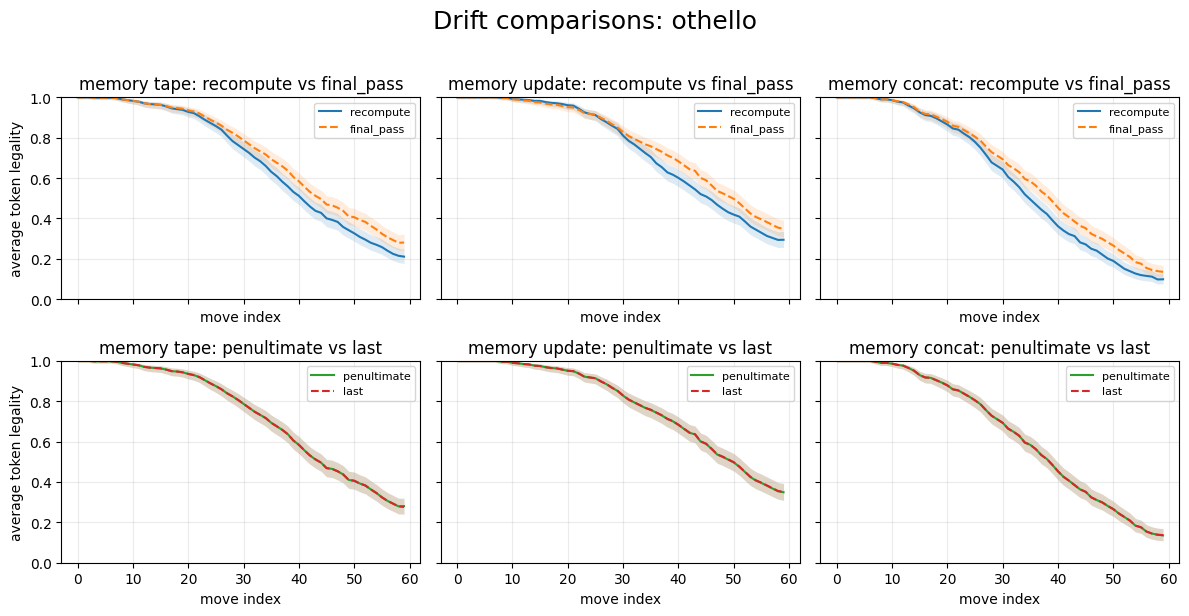

In [63]:
def _wilson_interval(p, n, z=1.96):
    if n <= 0 or pd.isna(p):
        return float("nan"), float("nan")
    denom = 1.0 + (z * z) / n
    center = (p + (z * z) / (2.0 * n)) / denom
    margin = (z * math.sqrt((p * (1.0 - p) / n) + ((z * z) / (4.0 * n * n)))) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

def _plot_legality_curve(ax, group, *, label, color, linestyle):
    group = group.sort_values("position")
    positions = group["position"].to_numpy(dtype=float)
    counts = group["count"].to_numpy(dtype=float)
    token_legality = group["token_legality"].to_numpy(dtype=float)
    intervals = [_wilson_interval(p, n) for p, n in zip(token_legality, counts)]
    lower = [interval[0] for interval in intervals]
    upper = [interval[1] for interval in intervals]
    line, = ax.plot(positions, token_legality, label=label, color=color, linestyle=linestyle)
    ax.fill_between(positions, lower, upper, color=line.get_color(), alpha=0.14, linewidth=0)

architectures = ARCHITECTURES_TO_PLOT or sorted(per_position_df["architecture"].dropna().unique())
architectures = list(dict.fromkeys(architectures))[:3]
mode_compare_cache = "penultimate"
cache_compare_mode = "final_pass"
task_label = ", ".join(TASKS_TO_PLOT) if TASKS_TO_PLOT else "trace"

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
fig.suptitle(f"Drift comparisons: {task_label}", fontsize=18, y=1.02)

if per_position_df.empty:
    for ax in axes.flat:
        ax.text(0.5, 0.5, "No per-position drift rows found", ha="center", va="center")
        ax.set_axis_off()
else:
    mode_styles = {
        "recompute": {"color": "tab:blue", "linestyle": "-"},
        "final_pass": {"color": "tab:orange", "linestyle": "--"},
    }
    cache_styles = {
        "penultimate": {"color": "tab:green", "linestyle": "-"},
        "last": {"color": "tab:red", "linestyle": "--"},
    }

    for col in range(3):
        top_ax = axes[0, col]
        bottom_ax = axes[1, col]
        if col >= len(architectures):
            top_ax.set_axis_off()
            bottom_ax.set_axis_off()
            continue

        architecture = architectures[col]
        pretty_arch = architecture.replace("_", " ")

        mode_df = per_position_df[
            (per_position_df["architecture"] == architecture)
            & (per_position_df["cache_source"] == mode_compare_cache)
            & (per_position_df["inference_mode"].isin(["recompute", "final_pass"]))
        ]
        for inference_mode in ["recompute", "final_pass"]:
            group = mode_df[mode_df["inference_mode"] == inference_mode]
            if group.empty:
                continue
            _plot_legality_curve(top_ax, group, label=inference_mode, **mode_styles[inference_mode])
        if top_ax.lines:
            top_ax.legend(fontsize=8)
        else:
            top_ax.text(0.5, 0.5, "No mode data", ha="center", va="center")
        top_ax.set_title(f"{pretty_arch}: recompute vs final_pass")

        cache_df = per_position_df[
            (per_position_df["architecture"] == architecture)
            & (per_position_df["inference_mode"] == cache_compare_mode)
            & (per_position_df["cache_source"].isin(["penultimate", "last"]))
        ]
        for cache_source in ["penultimate", "last"]:
            group = cache_df[cache_df["cache_source"] == cache_source]
            if group.empty:
                continue
            _plot_legality_curve(bottom_ax, group, label=cache_source, **cache_styles[cache_source])
        if bottom_ax.lines:
            bottom_ax.legend(fontsize=8)
        else:
            bottom_ax.text(0.5, 0.5, "No cache data", ha="center", va="center")
        bottom_ax.set_title(f"{pretty_arch}: penultimate vs last")

    for ax in axes.flat:
        if ax.axison:
            ax.set_ylim(0.0, 1.0)
            ax.set_xlabel("move index")
    for ax in axes[:, 0]:
        if ax.axison:
            ax.set_ylabel("average token legality")

plt.tight_layout()
